# Modelling

Disclaimer: this notebook has been written with the aid of [ChatGPT](https://chatgpt.com/share/6a943366-04c0-83eb-92f3-318be9f25bd0).

## Model Preparation

### Importing Libraries

In [76]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

from sklearn.inspection import permutation_importance

### Loading the Dataset

In [37]:
# Setting paths for the data folder and the .csv file
dataFolder = "C:/Users/sKALa/Repos/Semester 2/Dissertation/Albert Skalinski - Dissertation/data"
dataPath = dataFolder + "/cleanDataWithGroups.csv"

# Reading the cleaned dataset
df = pd.read_csv(dataPath)

# Checking if the data was read correctly
display(df.head())

,name,artist,genre,popularity,releaseDate,releaseYear,releaseMonth,timePeriod,energy,danceability,...,valence,speechiness,instrumentalness,acousticness,tempo,timeSignature,mode,key,durationMin,popularityGroup
0,Die With A Smile,"Lady Gaga, Bruno Mars",pop,100,2024-08-16,2024,8,2020s,0.592,0.521,...,0.535,0.0304,0.0000,0.3080,157.969,3,0,6,4.19,High popularity
1,BIRDS OF A FEATHER,Billie Eilish,pop,97,2024-05-17,2024,5,2020s,0.507,0.747,...,0.438,0.0358,0.0608,0.2000,104.978,4,1,2,3.51,High popularity
2,That’s So True,Gracie Abrams,pop,93,2024-10-18,2024,10,2020s,0.808,0.554,...,0.372,0.0368,0.0000,0.2140,108.548,4,1,1,2.77,High popularity
3,Taste,Sabrina Carpenter,pop,81,2024-08-23,2024,8,2020s,0.910,0.670,...,0.786,0.0634,0.0000,0.0939,112.966,4,0,0,2.62,High popularity
4,APT.,"ROSÉ, Bruno Mars",pop,98,2024-10-18,2024,10,2020s,0.783,0.777,...,0.939,0.2600,0.0000,0.0283,149.027,4,0,0,2.83,High popularity


### Checking the Dataset

In [38]:
# Checking the shape of the dataset
print("Dataset shape:", df.shape)

# Checking for missing values
print("Number of missing values:", df.isna().sum().sum())

Dataset shape: (4368, 22)
Number of missing values: 0


### Selecting the Audio Features and Target

In [39]:
# Selecting audio features
audioFeatures = ["energy", "danceability", "loudness", "liveness", "valence", "speechiness", "instrumentalness", "acousticness", "tempo",
                "durationMin"]

# Defining the target variable
target = "popularity"

key, mode, and timeSignature were left out, since they weren't really analysed before.

### Creating X and y

In [40]:
# Creating predictor and target datasets
X = df[audioFeatures]
y = df[target]

# Checking the data
display(X.head())
display(y.head())

,energy,danceability,loudness,liveness,valence,speechiness,instrumentalness,acousticness,tempo,durationMin
0,0.592,0.521,-7.777,0.122,0.535,0.0304,0.0000,0.3080,157.969,4.19
1,0.507,0.747,-10.171,0.117,0.438,0.0358,0.0608,0.2000,104.978,3.51
2,0.808,0.554,-4.169,0.159,0.372,0.0368,0.0000,0.2140,108.548,2.77
3,0.910,0.670,-4.070,0.304,0.786,0.0634,0.0000,0.0939,112.966,2.62
4,0.783,0.777,-4.477,0.355,0.939,0.2600,0.0000,0.0283,149.027,2.83


0    100
1     97
2     93
3     81
4     98
Name: popularity, dtype: int64

In [41]:
# Checking the shapes
print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (4368, 10)
Target shape: (4368,)


### Train/Test Split

In [42]:
# Splitting the dataset into training and testing sets
XTrain, XTest, yTrain, yTest = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Checking the sizes of the resulting datasets
print("XTrain shape:", XTrain.shape)
print("XTest shape:", XTest.shape)
print("yTrain shape:", yTrain.shape)
print("yTest shape:", yTest.shape)

XTrain shape: (3494, 10)
XTest shape: (874, 10)
yTrain shape: (3494,)
yTest shape: (874,)


### Checking the Target Distribution After Splitting

In [43]:
# Comparing popularity in the training and testing sets
print("Training popularity:")
display(yTrain.describe())

print("Testing popularity:")
display(yTest.describe())

Training popularity:


count    3494.000000
mean       52.935318
std        19.403024
min        11.000000
25%        39.000000
50%        53.000000
75%        70.000000
max       100.000000
Name: popularity, dtype: float64

Testing popularity:


count    874.000000
mean      53.787185
std       19.927716
min       11.000000
25%       39.000000
50%       55.000000
75%       71.000000
max       93.000000
Name: popularity, dtype: float64

In [44]:
# Comparing average popularity between training and testing sets
print("Training mean popularity:", round(yTrain.mean(), 2))
print("Testing mean popularity:", round(yTest.mean(), 2))

Training mean popularity: 52.94
Testing mean popularity: 53.79


## Baseline Model - Linear Regression

### Standardising the Features

In [45]:
# Creating the scaler
scaler = StandardScaler()

# Fitting the scaler on the training data and transforming both sets
XTrainScaled = scaler.fit_transform(XTrain)
XTestScaled = scaler.transform(XTest)

### Training the Linear Regression Model

In [46]:
# Creating the baseline Linear Regression model
linearModel = LinearRegression()

# Training the model
linearModel.fit(XTrainScaled, yTrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Making Predictions

In [47]:
# Predicting popularity for the testing set
linearPredictions = linearModel.predict(XTestScaled)

# Displaying the first few predictions
display(linearPredictions[:10])

array([51.73407602, 43.41389561, 51.97910695, 58.49890298, 54.56873195,
       54.8259875 , 58.9451151 , 53.02520602, 52.8913777 , 52.9877539 ])

### Evaluating Linear Regression

In [48]:
# Calculating Linear Regression performance metrics
linearMAE = mean_absolute_error(yTest, linearPredictions)
linearRMSE = np.sqrt(mean_squared_error(yTest, linearPredictions))
linearR2 = r2_score(yTest, linearPredictions)

# Displaying the results
print("Linear Regression Results")
print("MAE:", round(linearMAE, 2))
print("RMSE:", round(linearRMSE, 2))
print("R²:", round(linearR2, 3))

Linear Regression Results
MAE: 16.13
RMSE: 19.26
R²: 0.065


### Results Table

In [49]:
# Creating a table for model performance
modelResults = pd.DataFrame({"Model" : ["Linear Regression"], "MAE" : [linearMAE], "RMSE" : [linearRMSE], "R2" : [linearR2]})

display(modelResults.round(3))

,Model,MAE,RMSE,R2
0,Linear Regression,16.132,19.261,0.065


### Linear Regression Coefficients

In [50]:
# Creating a table of Linear Regression coefficients
linearCoefficients = pd.DataFrame({"Feature" : audioFeatures, "Coefficient" : linearModel.coef_})

# Ordering features by coefficient
linearCoefficients = linearCoefficients.sort_values(by = "Coefficient", ascending = False)

display(linearCoefficients.round(3))

,Feature,Coefficient
1,danceability,0.584
2,loudness,0.559
8,tempo,0.250
3,liveness,-0.257
9,durationMin,-0.463
5,speechiness,-0.858
0,energy,-1.022
4,valence,-1.114
7,acousticness,-2.842
6,instrumentalness,-3.973


- positive coefficient - higher feature value is associated with greated predicted popularity
- negative coefficient - higher feature value is associated with lower predicted popularity
- coefficient close to zero - weak linear contribution after accounting for the other predictors

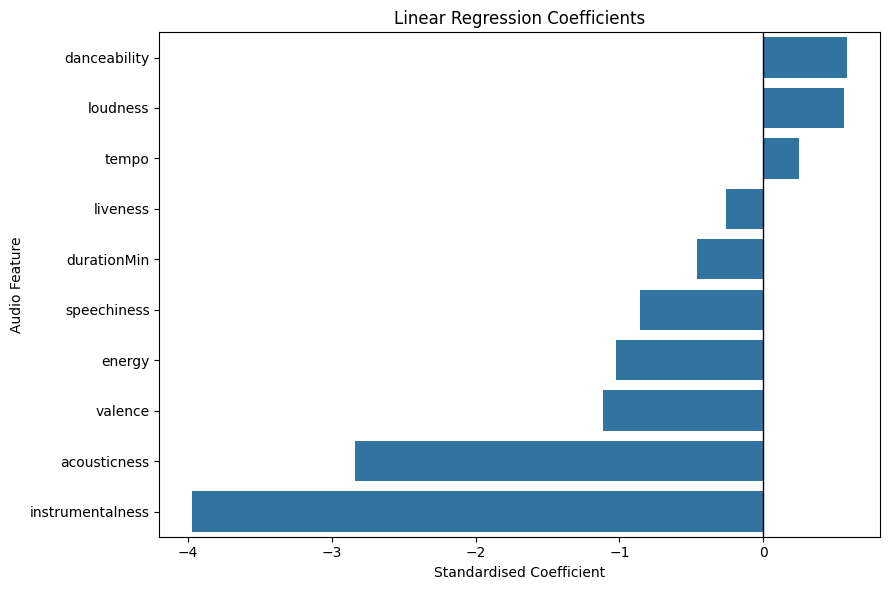

In [51]:
# Linear Regression coefficients
plt.figure(figsize = (9, 6))

sns.barplot(data = linearCoefficients, x = "Coefficient", y = "Feature")

plt.title("Linear Regression Coefficients")
plt.xlabel("Standardised Coefficient")
plt.ylabel("Audio Feature")
plt.axvline(x = 0, color = "black", linewidth = 1)
plt.tight_layout()
plt.show()

### Actual vs Predicted Popularity

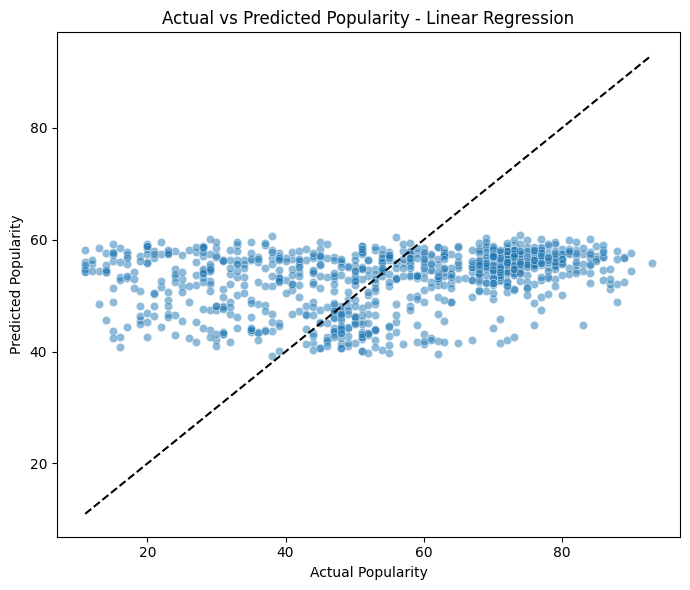

In [52]:
# Actual vs predicted popularity
plt.figure(figsize = (7, 6))

sns.scatterplot(x = yTest, y = linearPredictions, alpha = 0.5)

# Adding perfect prediction reference line
minimumValue = min(yTest.min(), linearPredictions.min())
maximumValue = max(yTest.max(), linearPredictions.max())

plt.plot([minimumValue, maximumValue], [minimumValue, maximumValue], linestyle = "--", color = "black")

plt.title("Actual vs Predicted Popularity - Linear Regression")
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.tight_layout()
plt.show()

Overall:
- MAE = 16.13 - predictions are off by ~16 popularity points on average
- R^2 - the audio features explain ~6.5% off the variation in popularity in the model
- the model is regressing toward the mean and failing to capture low- and high-popularity tracks
- instrumentalness and acousticness have the strongest negative coefficients

## XGBoost

### Creating the XGBoost Model

In [53]:
# Creating the XGBoost regression model
xgbModel = XGBRegressor(n_estimators = 300, learning_rate = 0.05, max_depth = 4, subsample = 0.8, colsample_bytree = 0.8,
                       objective = "reg:squarederror", random_state = 42)

# Training the model
xgbModel.fit(XTrain, yTrain)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Moderate settings instead of complex ones.

### Making XGBoost Predictions

In [54]:
# Predicting popularity for the testing set
xgbPredictions = xgbModel.predict(XTest)

# Displaying the first few predictions
display(xgbPredictions[:10])

array([42.532402, 42.568256, 50.548252, 55.58126 , 46.007362, 63.01289 ,
       51.3519  , 63.99071 , 45.392876, 47.843548], dtype=float32)

### Evaluating XGBoost

In [55]:
# Calculating XGBoost performance metrics
xgbMAE = mean_absolute_error(yTest, xgbPredictions)
xgbRMSE = np.sqrt(mean_squared_error(yTest, xgbPredictions))
xgbR2 = r2_score(yTest, xgbPredictions)

# Displaying the results
print("XGBoost Results")
print("MAE:", round(xgbMAE, 2))
print("RMSE:", round(xgbRMSE, 2))
print("R²:", round(xgbR2, 3))

XGBoost Results
MAE: 15.2
RMSE: 18.67
R²: 0.121


### Updating the Model Comparison Table

In [56]:
# Adding XGBoost results to the model comparison table
xgbResults = pd.DataFrame({"Model" : ["XGBoost"], "MAE" : [xgbMAE], "RMSE" : [xgbRMSE], "R2" : [xgbR2]})

modelResults = pd.concat([modelResults, xgbResults], ignore_index = True)

display(modelResults.round(3))

,Model,MAE,RMSE,R2
0,Linear Regression,16.132,19.261,0.065
1,XGBoost,15.201,18.673,0.121


### Actual vs Predicted — XGBoost

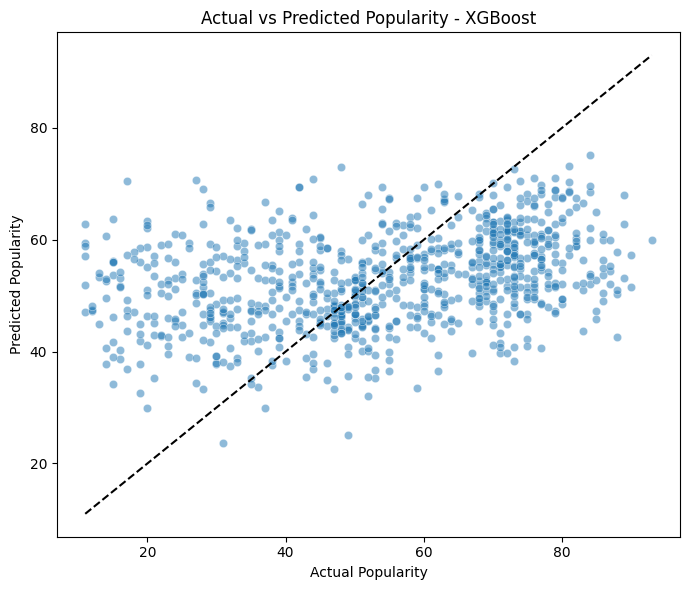

In [57]:
# Actual vs predicted popularity for XGBoost
plt.figure(figsize = (7, 6))

sns.scatterplot(x = yTest, y = xgbPredictions, alpha = 0.5)

# Adding perfect prediction reference line
minimumValue = min(yTest.min(), xgbPredictions.min())
maximumValue = max(yTest.max(), xgbPredictions.max())

plt.plot([minimumValue, maximumValue], [minimumValue, maximumValue], linestyle = "--", color = "black")

plt.title("Actual vs Predicted Popularity - XGBoost")
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.tight_layout()
plt.show()

### Global XGBoost Feature Importance

In [58]:
# Creating a table of XGBoost feature importance
xgbImportance = pd.DataFrame({"Feature" : audioFeatures, "Importance" : xgbModel.feature_importances_})

xgbImportance = xgbImportance.sort_values(by = "Importance", ascending = False)

display(xgbImportance.round(3))

,Feature,Importance
2,loudness,0.161
6,instrumentalness,0.143
9,durationMin,0.098
7,acousticness,0.097
4,valence,0.089
1,danceability,0.088
8,tempo,0.085
5,speechiness,0.084
0,energy,0.082
3,liveness,0.072


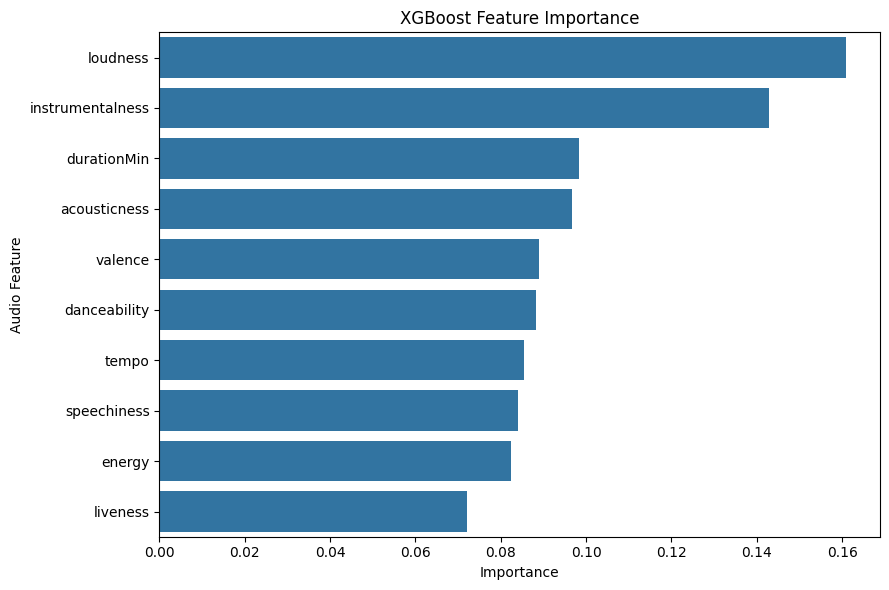

In [59]:
# XGBoost feature importance
plt.figure(figsize = (9, 6))

sns.barplot(data = xgbImportance, x = "Importance", y = "Feature")

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Audio Feature")
plt.tight_layout()
plt.show()

Overall:
- R^2 improved, while MAE falls - the nonlinear model performs better

## XGBoost Hyperparameter Optimisation

### Defining the Parameter Search

In [60]:
# Defining a small set of parameters to test
xgbParameters = {"n_estimators" : [200, 300, 400], "learning_rate" : [0.03, 0.05, 0.1], "max_depth" : [3, 4, 5], "gamma" : [0, 0.1, 0.2],
                "subsample" : [0.8, 1.0], "colsample_bytree" : [0.8, 1.0]}

5 parameter combinations with 3-fold cross-validation = 15 model fits.

### Running the Search

In [61]:
# Creating the base XGBoost model
xgbBaseModel = XGBRegressor(objective = "reg:squarederror", tree_method = "hist", random_state = 42, n_jobs = 1)

# Creating a lightweight randomised search
xgbSearch = RandomizedSearchCV(estimator = xgbBaseModel, param_distributions = xgbParameters, n_iter = 5,
                              scoring = "neg_root_mean_squared_error", cv = 3, random_state = 42, n_jobs = -1)

# Running the optimisation
xgbSearch.fit(XTrain, yTrain)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1, ...], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can 

### Best Parameters

In [62]:
# Displaying the best parameters
print("Best parameters:")
print(xgbSearch.best_params_)

# Displaying the best cross-validation RMSE
print("Best cross-validation RMSE:", round(-xgbSearch.best_score_, 2))

Best parameters:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0.2, 'colsample_bytree': 0.8}
Best cross-validation RMSE: 18.17


### Creating the Optimised Model

In [63]:
# Selecting the best XGBoost model
xgbOptimisedModel = xgbSearch.best_estimator_

# Making predictions on the untouched testing set
xgbOptimisedPredictions = xgbOptimisedModel.predict(XTest)

### Evaluating the Optimised Model

In [64]:
# Calculating optimised XGBoost performance metrics
xgbOptimisedMAE = mean_absolute_error(yTest, xgbOptimisedPredictions)

xgbOptimisedRMSE = np.sqrt(mean_squared_error(yTest, xgbOptimisedPredictions))

xgbOptimisedR2 = r2_score(yTest, xgbOptimisedPredictions)

# Displaying the results
print("Optimised XGBoost Results")
print("MAE:", round(xgbOptimisedMAE, 2))
print("RMSE:", round(xgbOptimisedRMSE, 2))
print("R²:", round(xgbOptimisedR2, 3))

Optimised XGBoost Results
MAE: 15.33
RMSE: 18.69
R²: 0.12


### Adding It to the Comparison Table

In [65]:
# Adding optimised XGBoost results to the comparison table
optimisedResults = pd.DataFrame({"Model" : ["Optimised XGBoost"], "MAE" : [xgbOptimisedMAE], "RMSE" : [xgbOptimisedRMSE],
                               "R2" : [xgbOptimisedR2]})

modelResults = pd.concat([modelResults, optimisedResults], ignore_index = True)

display(modelResults.round(3))

,Model,MAE,RMSE,R2
0,Linear Regression,16.132,19.261,0.065
1,XGBoost,15.201,18.673,0.121
2,Optimised XGBoost,15.330,18.688,0.120


### Actual vs Predicted for the Final Model

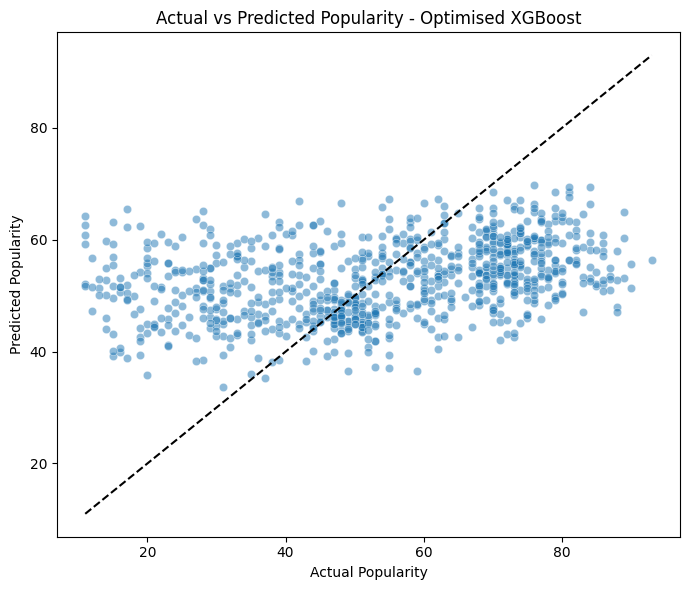

In [66]:
# Actual vs predicted popularity for optimised XGBoost
plt.figure(figsize = (7, 6))

sns.scatterplot(x = yTest, y = xgbOptimisedPredictions, alpha = 0.5)

# Adding perfect prediction reference line
minimumValue = min(yTest.min(), xgbOptimisedPredictions.min())

maximumValue = max(yTest.max(), xgbOptimisedPredictions.max())

plt.plot([minimumValue, maximumValue], [minimumValue, maximumValue], linestyle = "--", color = "black")

plt.title("Actual vs Predicted Popularity - Optimised XGBoost")
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.tight_layout()
plt.show()

Overall:
- original and optimised XGBoost results are super similar - hyperparameter tuning didn't produce a meaningful gain

## Audio + Genre + Release Year Model

### Creating the Contextual Dataset

In [67]:
# Selecting contextual features
contextFeatures = audioFeatures + ["releaseYear", "genre"]

# Creating the contextual predictor dataset
XContext = df[contextFeatures].copy()

display(XContext.head())

,energy,danceability,loudness,liveness,valence,speechiness,instrumentalness,acousticness,tempo,durationMin,releaseYear,genre
0,0.592,0.521,-7.777,0.122,0.535,0.0304,0.0000,0.3080,157.969,4.19,2024,pop
1,0.507,0.747,-10.171,0.117,0.438,0.0358,0.0608,0.2000,104.978,3.51,2024,pop
2,0.808,0.554,-4.169,0.159,0.372,0.0368,0.0000,0.2140,108.548,2.77,2024,pop
3,0.910,0.670,-4.070,0.304,0.786,0.0634,0.0000,0.0939,112.966,2.62,2024,pop
4,0.783,0.777,-4.477,0.355,0.939,0.2600,0.0000,0.0283,149.027,2.83,2024,pop


### Encoding Genre

In [68]:
# One-hot encoding the genre variable
XContext = pd.get_dummies(XContext, columns = ["genre"], dtype = int)

# Checking the resulting dataset
print("Contextual predictor shape:", XContext.shape)
display(XContext.head())

Contextual predictor shape: (4368, 46)


,energy,danceability,loudness,liveness,valence,speechiness,instrumentalness,acousticness,tempo,durationMin,...,genre_pop,genre_punk,genre_r&b,genre_reggae,genre_rock,genre_soca,genre_soul,genre_turkish,genre_wellness,genre_world
0,0.592,0.521,-7.777,0.122,0.535,0.0304,0.0000,0.3080,157.969,4.19,...,1,0,0,0,0,0,0,0,0,0
1,0.507,0.747,-10.171,0.117,0.438,0.0358,0.0608,0.2000,104.978,3.51,...,1,0,0,0,0,0,0,0,0,0
2,0.808,0.554,-4.169,0.159,0.372,0.0368,0.0000,0.2140,108.548,2.77,...,1,0,0,0,0,0,0,0,0,0
3,0.910,0.670,-4.070,0.304,0.786,0.0634,0.0000,0.0939,112.966,2.62,...,1,0,0,0,0,0,0,0,0,0
4,0.783,0.777,-4.477,0.355,0.939,0.2600,0.0000,0.0283,149.027,2.83,...,1,0,0,0,0,0,0,0,0,0


### Using the Same Train/Test Split

In [69]:
# Using the same training and testing observations as the audio-only models
XContextTrain = XContext.loc[XTrain.index]
XContextTest = XContext.loc[XTest.index]

# Checking the shapes
print("XContextTrain shape:", XContextTrain.shape)
print("XContextTest shape:", XContextTest.shape)
print("yTrain shape:", yTrain.shape)
print("yTest shape:", yTest.shape)

XContextTrain shape: (3494, 46)
XContextTest shape: (874, 46)
yTrain shape: (3494,)
yTest shape: (874,)


### Training the Contextual XGBoost Model

In [70]:
# Creating the contextual XGBoost model
xgbContextModel = XGBRegressor(n_estimators = 200, learning_rate = 0.03, max_depth = 3, gamma = 0.2, subsample = 0.8, colsample_bytree = 0.8,
                              objective = "reg:squarederror", tree_method = "hist", random_state = 42)

# Training the contextual model
xgbContextModel.fit(XContextTrain, yTrain)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Contextual Model Predictions

In [71]:
# Predicting popularity using audio and contextual features
contextPredictions = xgbContextModel.predict(XContextTest)

### Evaluating the Contextual Mode

In [72]:
# Calculating contextual model performance metrics
contextMAE = mean_absolute_error(yTest, contextPredictions)

contextRMSE = np.sqrt(mean_squared_error(yTest, contextPredictions)
)

contextR2 = r2_score(yTest, contextPredictions)

# Displaying the results
print("Contextual XGBoost Results")
print("MAE:", round(contextMAE, 2))
print("RMSE:", round(contextRMSE, 2))
print("R²:", round(contextR2, 3))

Contextual XGBoost Results
MAE: 12.8
RMSE: 16.15
R²: 0.342


### Audio-Only vs Contextual Model

In [73]:
# Comparing audio-only and contextual models
contextComparison = pd.DataFrame({"Model" : ["Audio Only", "Audio + Genre + Release Year"], "MAE" : [xgbOptimisedMAE, contextMAE],
                                "RMSE" : [xgbOptimisedRMSE, contextRMSE], "R2" : [xgbOptimisedR2, contextR2]})

display(contextComparison.round(3))

,Model,MAE,RMSE,R2
0,Audio Only,15.330,18.688,0.120
1,Audio + Genre + Release Year,12.796,16.153,0.342


In [74]:
# Calculating the change in model performance
print("MAE improvement:", round(xgbOptimisedMAE - contextMAE, 2))

print("RMSE improvement:", round(xgbOptimisedRMSE - contextRMSE, 2))

print("R² improvement:", round(contextR2 - xgbOptimisedR2, 3))

MAE improvement: 2.53
RMSE improvement: 2.53
R² improvement: 0.223


Overall:
- the contextual model imrpoves R^2 greatly and reduces MAE & RMSE

## Temporal Modelling

### Creating Modelling Periods

In [75]:
# Creating broader time periods for temporal modelling
def assignModelPeriod(year):
    if year < 2000:
        return "Pre-2000"
    elif year < 2010:
        return "2000s"
    elif year < 2020:
        return "2010s"
    else:
        return "2020s"

df["modelPeriod"] = df["releaseYear"].apply(assignModelPeriod)

# Defining period order
modelPeriodOrder = ["Pre-2000", "2000s", "2010s", "2020s"]

# Checking the number of tracks in each period
display(df["modelPeriod"].value_counts().reindex(modelPeriodOrder))

modelPeriod
Pre-2000     326
2000s        317
2010s        926
2020s       2799
Name: count, dtype: int64

The new periods were created to reduce imbalance.

### Training a Model for Each Time Period

In [77]:
# Creating empty lists for temporal results
temporalResults = []
temporalImportance = []

# Training one XGBoost model for each time period
for period in modelPeriodOrder:
    # Selecting tracks from the current period
    periodData = df[df["modelPeriod"] == period]

    XPeriod = periodData[audioFeatures]
    yPeriod = periodData["popularity"]

    # Splitting the period data
    XPeriodTrain, XPeriodTest, yPeriodTrain, yPeriodTest = train_test_split(XPeriod, yPeriod, test_size = 0.2, random_state = 42)

    # Creating the same XGBoost model for every period
    periodModel = XGBRegressor(n_estimators = 200, learning_rate = 0.03, max_depth = 3, gamma = 0.2, subsample = 0.8, colsample_bytree = 0.8,
                              objective = "reg:squarederror", tree_method = "hist", random_state = 42)

    # Training the model
    periodModel.fit(XPeriodTrain, yPeriodTrain)

    # Making predictions
    periodPredictions = periodModel.predict(XPeriodTest)

    # Calculating performance metrics
    periodMAE = mean_absolute_error(yPeriodTest, periodPredictions)

    periodRMSE = np.sqrt(mean_squared_error(yPeriodTest, periodPredictions))

    periodR2 = r2_score(yPeriodTest, periodPredictions)

    # Saving model performance
    temporalResults.append({"Time Period" : period, "Tracks" : len(periodData), "MAE" : periodMAE, "RMSE" : periodRMSE, "R2" : periodR2})

    # Calculating permutation importance
    permutationResults = permutation_importance(periodModel, XPeriodTest, yPeriodTest, scoring = "neg_root_mean_squared_error",
                                               n_repeats = 10, random_state = 42)

    # Saving feature importance
    for feature, importance in zip(audioFeatures, permutationResults.importances_mean):
        temporalImportance.append({"Time Period" : period, "Feature" : feature, "Importance" : importance})

### Temporal Model Performance

In [78]:
# Creating the temporal model performance table
temporalResults = pd.DataFrame(temporalResults)

display(temporalResults.round(3))

,Time Period,Tracks,MAE,RMSE,R2
0,Pre-2000,326,11.042,15.116,0.209
1,2000s,317,10.524,13.533,0.383
2,2010s,926,16.084,19.458,0.125
3,2020s,2799,13.029,16.646,0.149


### Preparing Temporal Feature Importance

In [79]:
# Creating the temporal feature importance dataframe
temporalImportance = pd.DataFrame(temporalImportance)

display(temporalImportance.head(10))

,Time Period,Feature,Importance
0,Pre-2000,energy,0.364379
1,Pre-2000,danceability,0.036960
2,Pre-2000,loudness,-0.218873
3,Pre-2000,liveness,0.398310
4,Pre-2000,valence,0.666791
5,Pre-2000,speechiness,0.299505
6,Pre-2000,instrumentalness,0.319188
7,Pre-2000,acousticness,1.775418
8,Pre-2000,tempo,0.272395
9,Pre-2000,durationMin,0.303621


In [80]:
# Reshaping feature importance for comparison
importanceByPeriod = temporalImportance.pivot(index = "Feature", columns = "Time Period", values = "Importance")

# Reordering the periods
importanceByPeriod = importanceByPeriod[modelPeriodOrder]

display(importanceByPeriod.round(3))

Time Period,Pre-2000,2000s,2010s,2020s
Feature,,,,
acousticness,1.775,3.919,0.396,0.044
danceability,0.037,-0.352,0.264,0.349
durationMin,0.304,0.073,0.278,0.183
energy,0.364,1.397,0.484,0.294
instrumentalness,0.319,0.211,0.424,0.235
liveness,0.398,0.126,0.121,0.060
loudness,-0.219,0.224,1.874,1.544
speechiness,0.300,-0.366,0.033,0.130
tempo,0.272,-0.099,0.156,0.033


### Feature Importance Heatmap

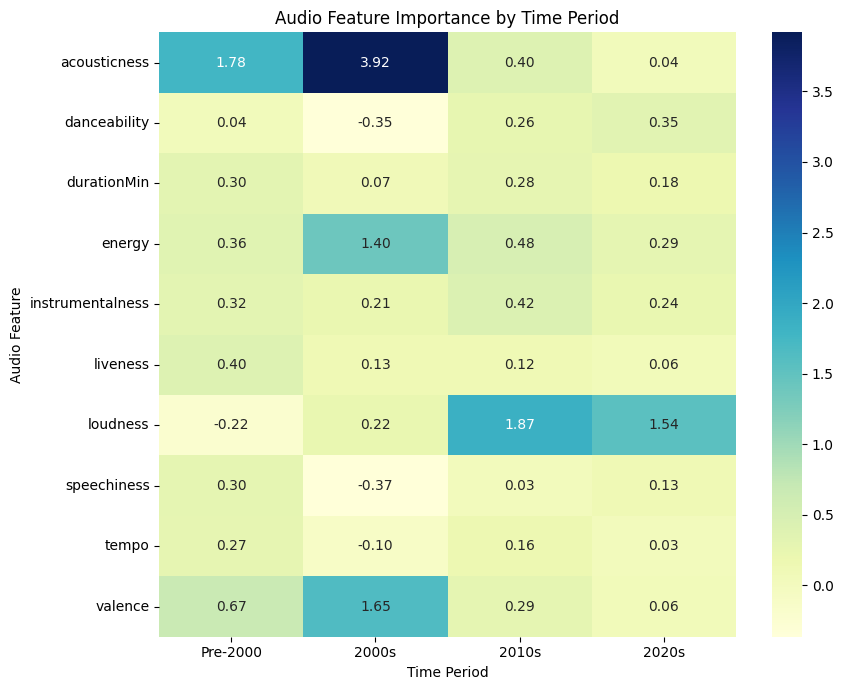

In [81]:
# Feature importance by time period
plt.figure(figsize = (9, 7))

sns.heatmap(importanceByPeriod, annot = True, fmt = ".2f", cmap = "YlGnBu")

plt.title("Audio Feature Importance by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Audio Feature")
plt.tight_layout()
plt.show()

### Most Important Features in Each Period

In [82]:
# Displaying the most important features in each time period
for period in modelPeriodOrder:
    print(period)

    display(temporalImportance[temporalImportance["Time Period"] == period].sort_values(by = "Importance",
           ascending = False).reset_index(drop = True).round(3))

Pre-2000


,Time Period,Feature,Importance
0,Pre-2000,acousticness,1.775
1,Pre-2000,valence,0.667
2,Pre-2000,liveness,0.398
3,Pre-2000,energy,0.364
4,Pre-2000,instrumentalness,0.319
5,Pre-2000,durationMin,0.304
6,Pre-2000,speechiness,0.300
7,Pre-2000,tempo,0.272
8,Pre-2000,danceability,0.037
9,Pre-2000,loudness,-0.219


2000s


,Time Period,Feature,Importance
0,2000s,acousticness,3.919
1,2000s,valence,1.652
2,2000s,energy,1.397
3,2000s,loudness,0.224
4,2000s,instrumentalness,0.211
5,2000s,liveness,0.126
6,2000s,durationMin,0.073
7,2000s,tempo,-0.099
8,2000s,danceability,-0.352
9,2000s,speechiness,-0.366


2010s


,Time Period,Feature,Importance
0,2010s,loudness,1.874
1,2010s,energy,0.484
2,2010s,instrumentalness,0.424
3,2010s,acousticness,0.396
4,2010s,valence,0.292
5,2010s,durationMin,0.278
6,2010s,danceability,0.264
7,2010s,tempo,0.156
8,2010s,liveness,0.121
9,2010s,speechiness,0.033


2020s


,Time Period,Feature,Importance
0,2020s,loudness,1.544
1,2020s,danceability,0.349
2,2020s,energy,0.294
3,2020s,instrumentalness,0.235
4,2020s,durationMin,0.183
5,2020s,speechiness,0.130
6,2020s,valence,0.063
7,2020s,liveness,0.060
8,2020s,acousticness,0.044
9,2020s,tempo,0.033


Overall:
- audio features appear more predictive within the 2000s subset than within more recent tracks